In [1]:
import torch

# 1. Check if CUDA is actually available
cuda_available = torch.cuda.is_available()
print(f"Is CUDA available? {cuda_available}")

if cuda_available:
    # 2. Print your GPU name (should say RTX 4050)
    print(f"Device Name: {torch.cuda.get_device_name(0)}")
    
    # 3. Set the device variable for the rest of your notebook
    device = torch.device("cuda")
else:
    device = torch.device("cpu")
    print("CUDA not found. Check your NVIDIA drivers.")

Is CUDA available? True
Device Name: NVIDIA GeForce RTX 4050 Laptop GPU


In [2]:
import os
os.environ["KAGGLE_USERNAME"] = "neeeeeeju"
os.environ["KAGGLE_KEY"] = "f787e5907b45402f7b2ff32912c00e8b"

In [3]:
!kaggle datasets download -d birdy654/cifake-real-and-ai-generated-synthetic-images


Dataset URL: https://www.kaggle.com/datasets/birdy654/cifake-real-and-ai-generated-synthetic-images
License(s): other
cifake-real-and-ai-generated-synthetic-images.zip: Skipping, found more recently modified local copy (use --force to force download)


In [4]:
import zipfile
import os
if not os.path.exists('train'):
    print('Extracting dataset...')
    with zipfile.ZipFile('cifake-real-and-ai-generated-synthetic-images.zip', 'r') as zip_ref:
        zip_ref.extractall('.')
    print('Extraction complete.')
else:
    print('Dataset already extracted.')

Dataset already extracted.


In [5]:
import os

for root, dirs, files in os.walk(".", topdown=True):
    print(root)
    break


.


In [6]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5],
                         [0.5, 0.5, 0.5])
])

train_dataset = datasets.ImageFolder("train", transform=transform)
test_dataset = datasets.ImageFolder("test", transform=transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)



In [7]:
print(train_dataset.classes)

['FAKE', 'REAL']


In [ ]:
import torchvision.models as models
from torchvision.models import ResNet18_Weights
import torch.nn as nn

model = models.resnet18(weights=ResNet18_Weights.DEFAULT)

model.fc = nn.Linear(model.fc.in_features, 2)
model = model.to(device)


In [9]:
!pip install -q tqdm



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [10]:
from tqdm import tqdm
import torch.optim as optim
import torch.nn as nn

num_epochs = 5

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    loop = tqdm(train_loader, leave=True)

    for images, labels in loop:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        loop.set_description(f"Epoch [{epoch+1}/{num_epochs}]")
        loop.set_postfix(
            loss=running_loss/len(train_loader),
            accuracy=100 * correct / total
        )
    
    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100 * correct / total
    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_acc)

    # --- Validation Phase ---
    model.eval()
    val_running_loss = 0.0
    val_correct = 0
    val_total = 0
    
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            val_running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()
            
    val_epoch_loss = val_running_loss / len(test_loader)
    val_epoch_acc = 100 * val_correct / val_total
    val_losses.append(val_epoch_loss)
    val_accuracies.append(val_epoch_acc)
    
    print(f"Epoch [{epoch+1}/{num_epochs}] - Train Loss: {epoch_loss:.4f}, Train Acc: {epoch_acc:.2f}% | Val Loss: {val_epoch_loss:.4f}, Val Acc: {val_epoch_acc:.2f}%")


print("Training Complete.")


Epoch [1/5]: 100%|██████████| 3125/3125 [21:04<00:00,  2.47it/s, accuracy=91.8, loss=0.207]  


Epoch [1/5] - Train Loss: 0.2069, Train Acc: 91.84% | Val Loss: 0.2202, Val Acc: 91.43%


Epoch [2/5]: 100%|██████████| 3125/3125 [06:48<00:00,  7.65it/s, accuracy=94.3, loss=0.15]  


Epoch [2/5] - Train Loss: 0.1501, Train Acc: 94.27% | Val Loss: 0.1234, Val Acc: 95.19%


Epoch [3/5]: 100%|██████████| 3125/3125 [06:17<00:00,  8.27it/s, accuracy=95.3, loss=0.124] 


Epoch [3/5] - Train Loss: 0.1237, Train Acc: 95.31% | Val Loss: 0.1094, Val Acc: 95.87%


Epoch [4/5]: 100%|██████████| 3125/3125 [06:18<00:00,  8.26it/s, accuracy=96, loss=0.106]   


Epoch [4/5] - Train Loss: 0.1065, Train Acc: 96.00% | Val Loss: 0.0920, Val Acc: 96.46%


Epoch [5/5]: 100%|██████████| 3125/3125 [06:12<00:00,  8.38it/s, accuracy=96.5, loss=0.0941]


Epoch [5/5] - Train Loss: 0.0941, Train Acc: 96.46% | Val Loss: 0.0895, Val Acc: 96.61%
Training Complete.


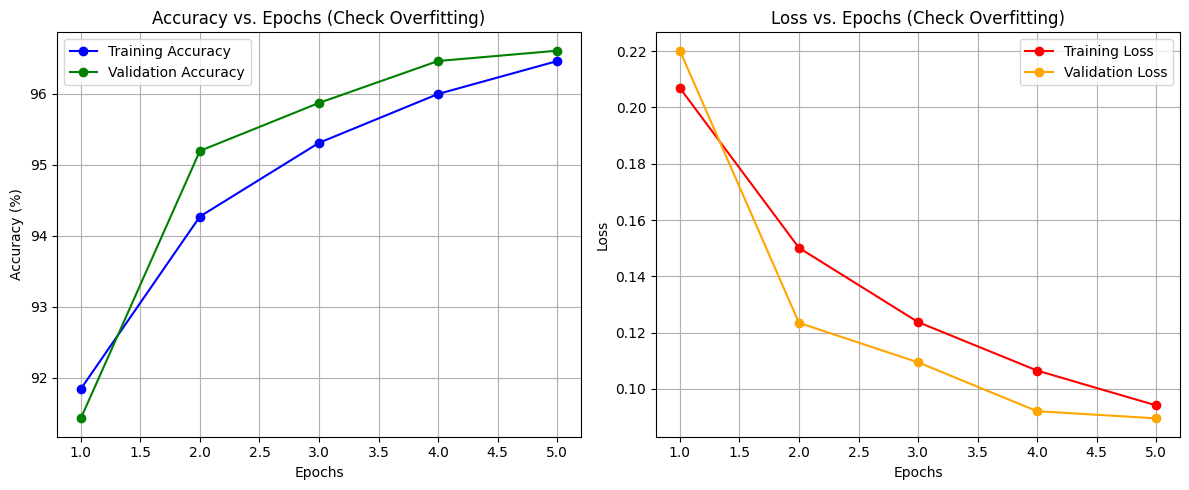

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(range(1, num_epochs+1), train_accuracies, marker='o', color='b', label='Training Accuracy')
plt.plot(range(1, num_epochs+1), val_accuracies, marker='o', color='g', label='Validation Accuracy')
plt.title('Accuracy vs. Epochs (Check Overfitting)')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(range(1, num_epochs+1), train_losses, marker='o', color='r', label='Training Loss')
plt.plot(range(1, num_epochs+1), val_losses, marker='o', color='orange', label='Validation Loss')
plt.title('Loss vs. Epochs (Check Overfitting)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [12]:
torch.save(model.state_dict(), "ai_detector_resnet18.pth")
print("Model saved successfully!")

Model saved successfully!


In [13]:
!pip install -q scikit-learn



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [14]:
import glob
print(glob.glob('./**/*.pth', recursive=True))


['.\\ai_detector_resnet18.pth', '.\\trained_models\\ai_detector_resnet18.pth']


In [15]:
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import numpy as np
import torch.nn.functional as F

model.eval()
all_preds = []
all_labels = []
all_probs = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        probs = F.softmax(outputs, dim=1)
        _, predicted = torch.max(outputs, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())
        all_probs.extend(probs.cpu().numpy())

all_probs = np.array(all_probs)
print(classification_report(all_labels, all_preds, target_names=train_dataset.classes))


              precision    recall  f1-score   support

        FAKE       0.98      0.96      0.97     10000
        REAL       0.96      0.98      0.97     10000

    accuracy                           0.97     20000
   macro avg       0.97      0.97      0.97     20000
weighted avg       0.97      0.97      0.97     20000



In [16]:
import os

drive_path = './trained_models'
model_path = 'ai_detector_resnet18.pth'

# Create the directory if it doesn't exist
os.makedirs(drive_path, exist_ok=True)

# Move the model file to the local directory
import shutil
if os.path.exists(model_path):
    shutil.move(model_path, os.path.join(drive_path, model_path))
    print(f"Model '{model_path}' moved to '{drive_path}'")
else:
    print(f"{model_path} not found.")


Model 'ai_detector_resnet18.pth' moved to './trained_models'


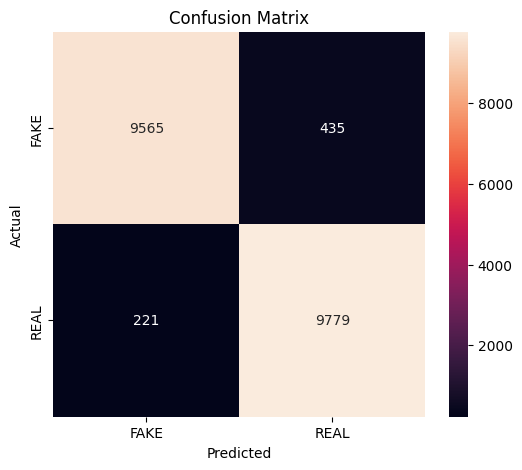

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=train_dataset.classes,
            yticklabels=train_dataset.classes)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


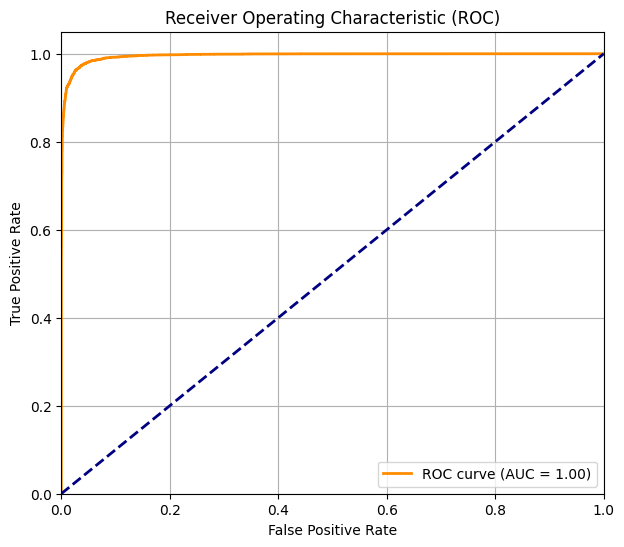

In [18]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

fpr, tpr, _ = roc_curve(all_labels, all_probs[:, 1])
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


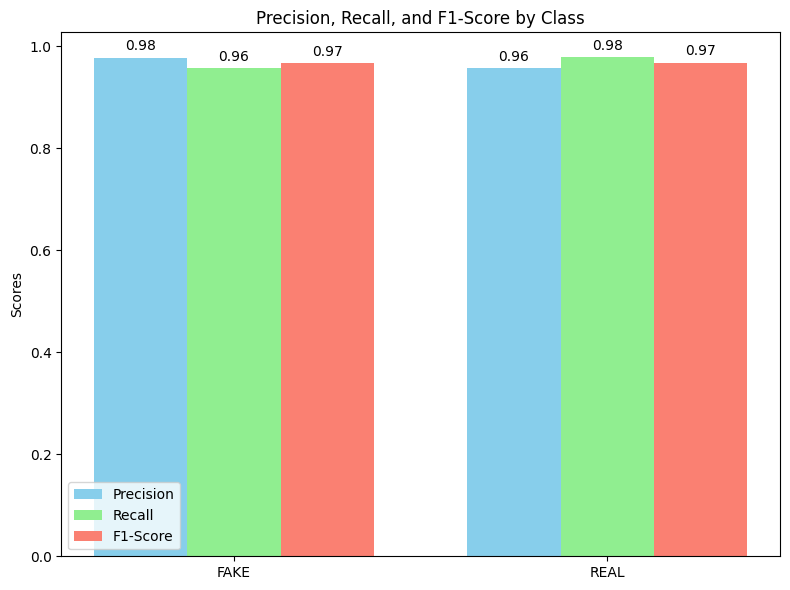

In [19]:
from sklearn.metrics import precision_recall_fscore_support
import numpy as np

precision, recall, f1, _ = precision_recall_fscore_support(all_labels, all_preds)

x = np.arange(len(train_dataset.classes))
width = 0.25

fig, ax = plt.subplots(figsize=(8, 6))
rects1 = ax.bar(x - width, precision, width, label='Precision', color='skyblue')
rects2 = ax.bar(x, recall, width, label='Recall', color='lightgreen')
rects3 = ax.bar(x + width, f1, width, label='F1-Score', color='salmon')

ax.set_ylabel('Scores')
ax.set_title('Precision, Recall, and F1-Score by Class')
ax.set_xticks(x)
ax.set_xticklabels(train_dataset.classes)
ax.legend(loc='lower left')

def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects1)
autolabel(rects2)
autolabel(rects3)

fig.tight_layout()
plt.show()


In [20]:
from PIL import Image

def predict_image(path):
    model.eval()
    image = Image.open(path).convert("RGB")
    image = transform(image).unsqueeze(0).to(device)

    output = model(image)
    _, pred = torch.max(output, 1)

    print("Prediction:", train_dataset.classes[pred.item()])


In [21]:
# Using a sample image from the test set for prediction
sample_image_path = test_dataset.samples[1000][0]  # Get a sample image path
print(f'Testing image: {sample_image_path}')
predict_image(sample_image_path)


Testing image: test\FAKE\189 (10).jpg
Prediction: FAKE


In [22]:
# Using a sample image from the test set for prediction
sample_image_path = test_dataset.samples[2000][0]  # Get a sample image path
print(f'Testing image: {sample_image_path}')
predict_image(sample_image_path)


Testing image: test\FAKE\279 (10).jpg
Prediction: FAKE
